# EDA

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
user_features_all = pd.read_csv('../data/processed/user_features.csv')
user_features = user_features_all.copy()



In [3]:
user_features_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5782 non-null   int64  
 1   gender                     5782 non-null   str    
 2   married                    5782 non-null   bool   
 3   has_children               5782 non-null   bool   
 4   home_country               5782 non-null   str    
 5   tenure                     5782 non-null   int64  
 6   age                        5782 non-null   int64  
 7   seats_avg                  4855 non-null   float64
 8   checked_bags_avg           4855 non-null   float64
 9   overcarrier                4855 non-null   object 
 10  total_trips                5782 non-null   int64  
 11  cancellation_rate          5336 non-null   float64
 12  unique_flight_destination  4984 non-null   float64
 13  taken_flights              5782 non-null   int64  
 14  fre

In [4]:
user_features_all.describe()

/home/anuarsantoyo/PycharmProjects/TravelTide_Mar/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,user_id,tenure,age,seats_avg,checked_bags_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate
count,5782.000000,5782.000000,5782.000000,4855.000000,4855.000000,5782.000000,5336.000000,4984.000000,5782.000000,4984.00,5782.000000,5242.000000
mean,547670.236077,1160.738499,43.610342,1.185156,0.579303,2.677966,0.048317,2.508828,2.576098,inf,0.322191,0.268851
std,64035.394540,34.194997,12.047354,0.367670,0.457929,1.520225,0.164389,1.210332,1.531541,NaN,0.190550,0.305426
min,94883.000000,1044.000000,19.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.20,0.000000,0.000000
25%,519413.750000,1145.000000,37.000000,1.000000,0.250000,2.000000,0.000000,2.000000,1.000000,0.75,0.166667,0.000000
50%,542279.500000,1162.000000,44.000000,1.000000,0.500000,3.000000,0.000000,2.000000,3.000000,1.00,0.333333,0.250000
75%,576215.500000,1173.000000,51.000000,1.250000,1.000000,4.000000,0.000000,3.000000,4.000000,1.00,0.500000,0.500000
max,844489.000000,1509.000000,90.000000,6.000000,5.000000,8.000000,1.000000,8.000000,8.000000,inf,1.000000,1.000000


## Age analysis

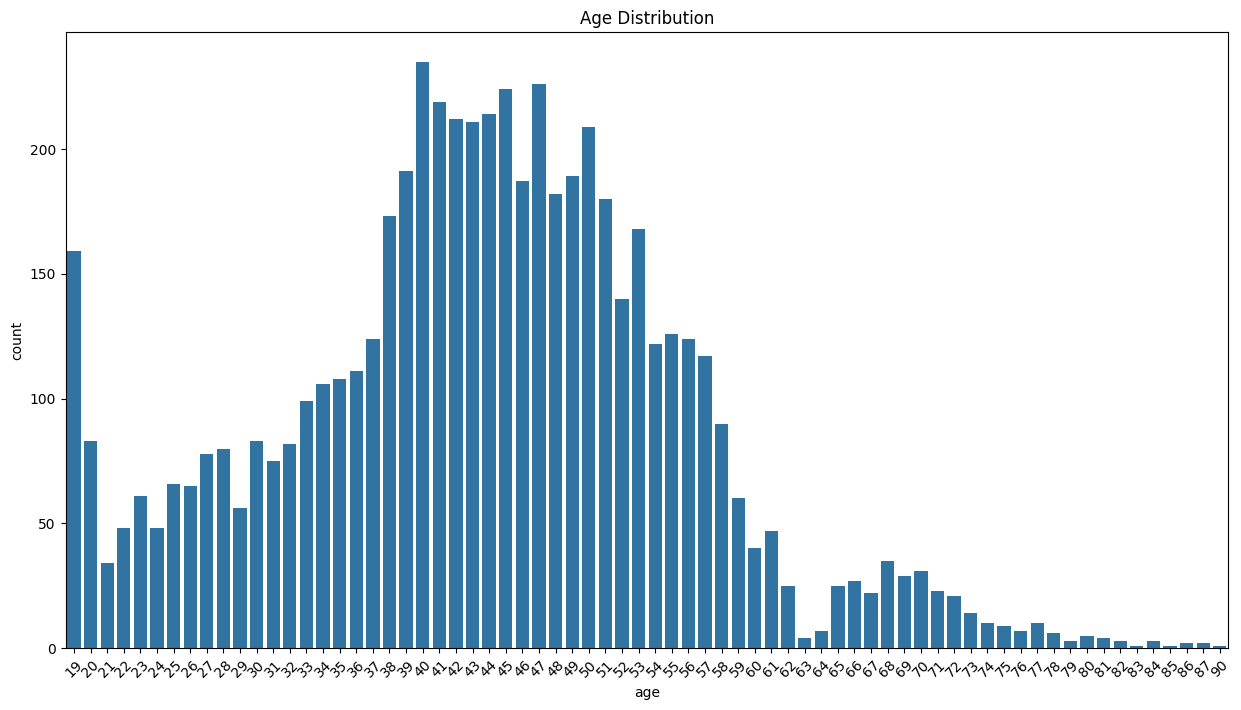

In [5]:
# Plot all countries with hue
plt.figure(figsize=(15, 8))
sns.countplot(data=user_features_all,
              x='age')
plt.title('Age Distribution')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

In [6]:
user_features_all['home_country'].value_counts().index

Index(['usa', 'canada'], dtype='str', name='home_country')

In [7]:
import matplotlib.pyplot as plt

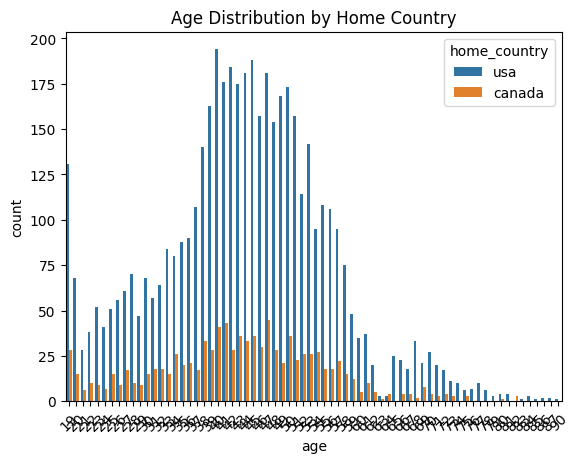

In [8]:
# Plot all countries with hue
sns.countplot(data=user_features_all,
              x='age',
              hue='home_country')
plt.title('Age Distribution by Home Country')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

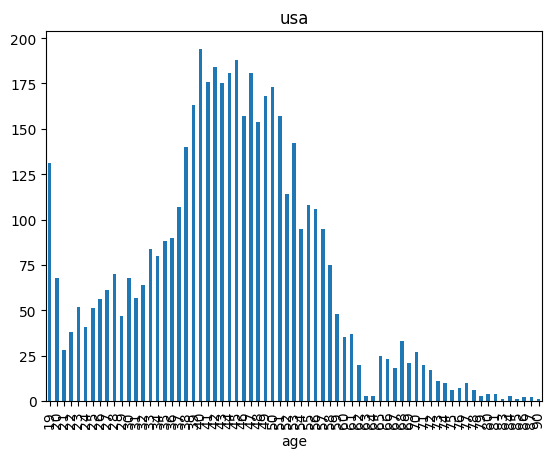

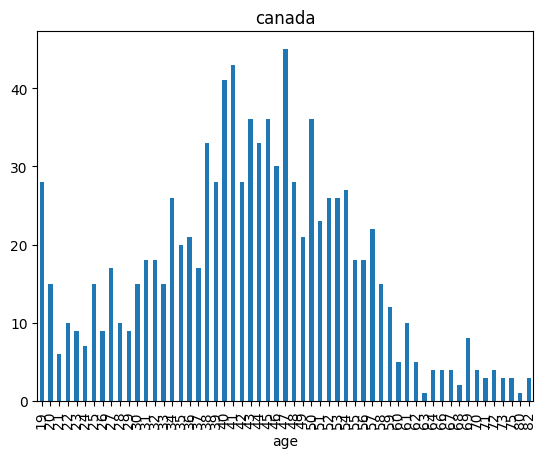

In [9]:
for country in user_features_all['home_country'].value_counts().index:
    user_features_all[user_features_all['home_country'] == country]['age'].value_counts().sort_index().plot(kind="bar")
    plt.title(country)
    plt.show()

In [10]:
user_features_all['gender'].value_counts(normalize=True)

gender
F    0.885161
M    0.112937
O    0.001902
Name: proportion, dtype: float64

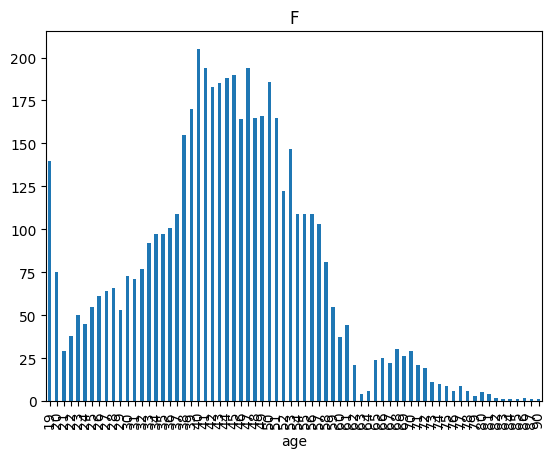

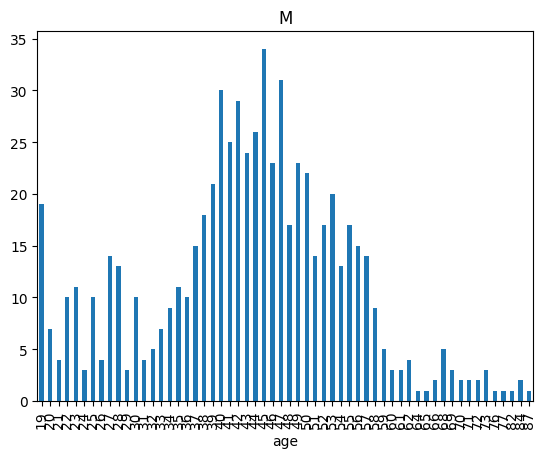

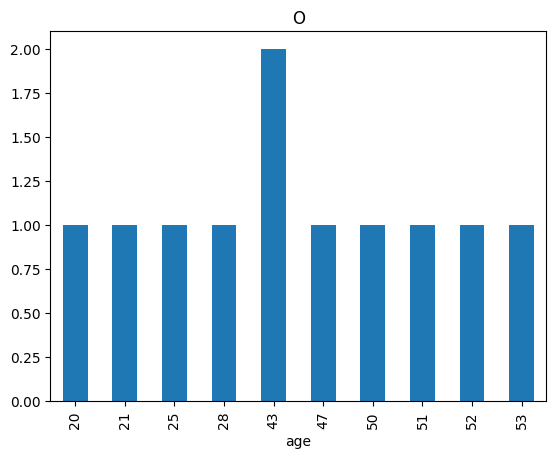

In [11]:
for gender in user_features_all['gender'].value_counts().index:
    user_features_all[user_features_all['gender'] == gender]['age'].value_counts().sort_index().plot(kind="bar")
    plt.title(gender)
    plt.show()

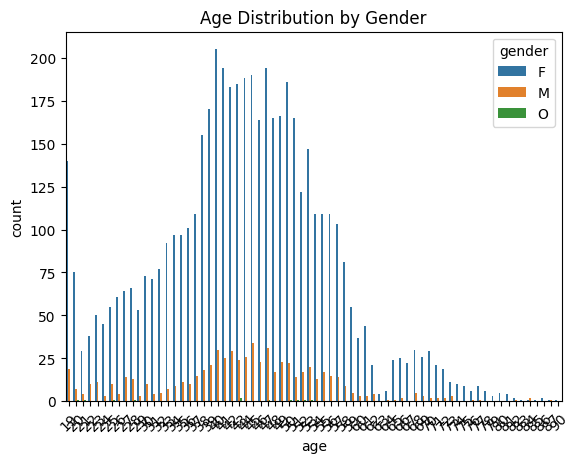

In [12]:
# Plot all countries with hue
sns.countplot(data=user_features_all,
              x='age',
              hue='gender')
plt.title('Age Distribution by Gender')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

## More EDA!!!!!!

KeyboardInterrupt: 

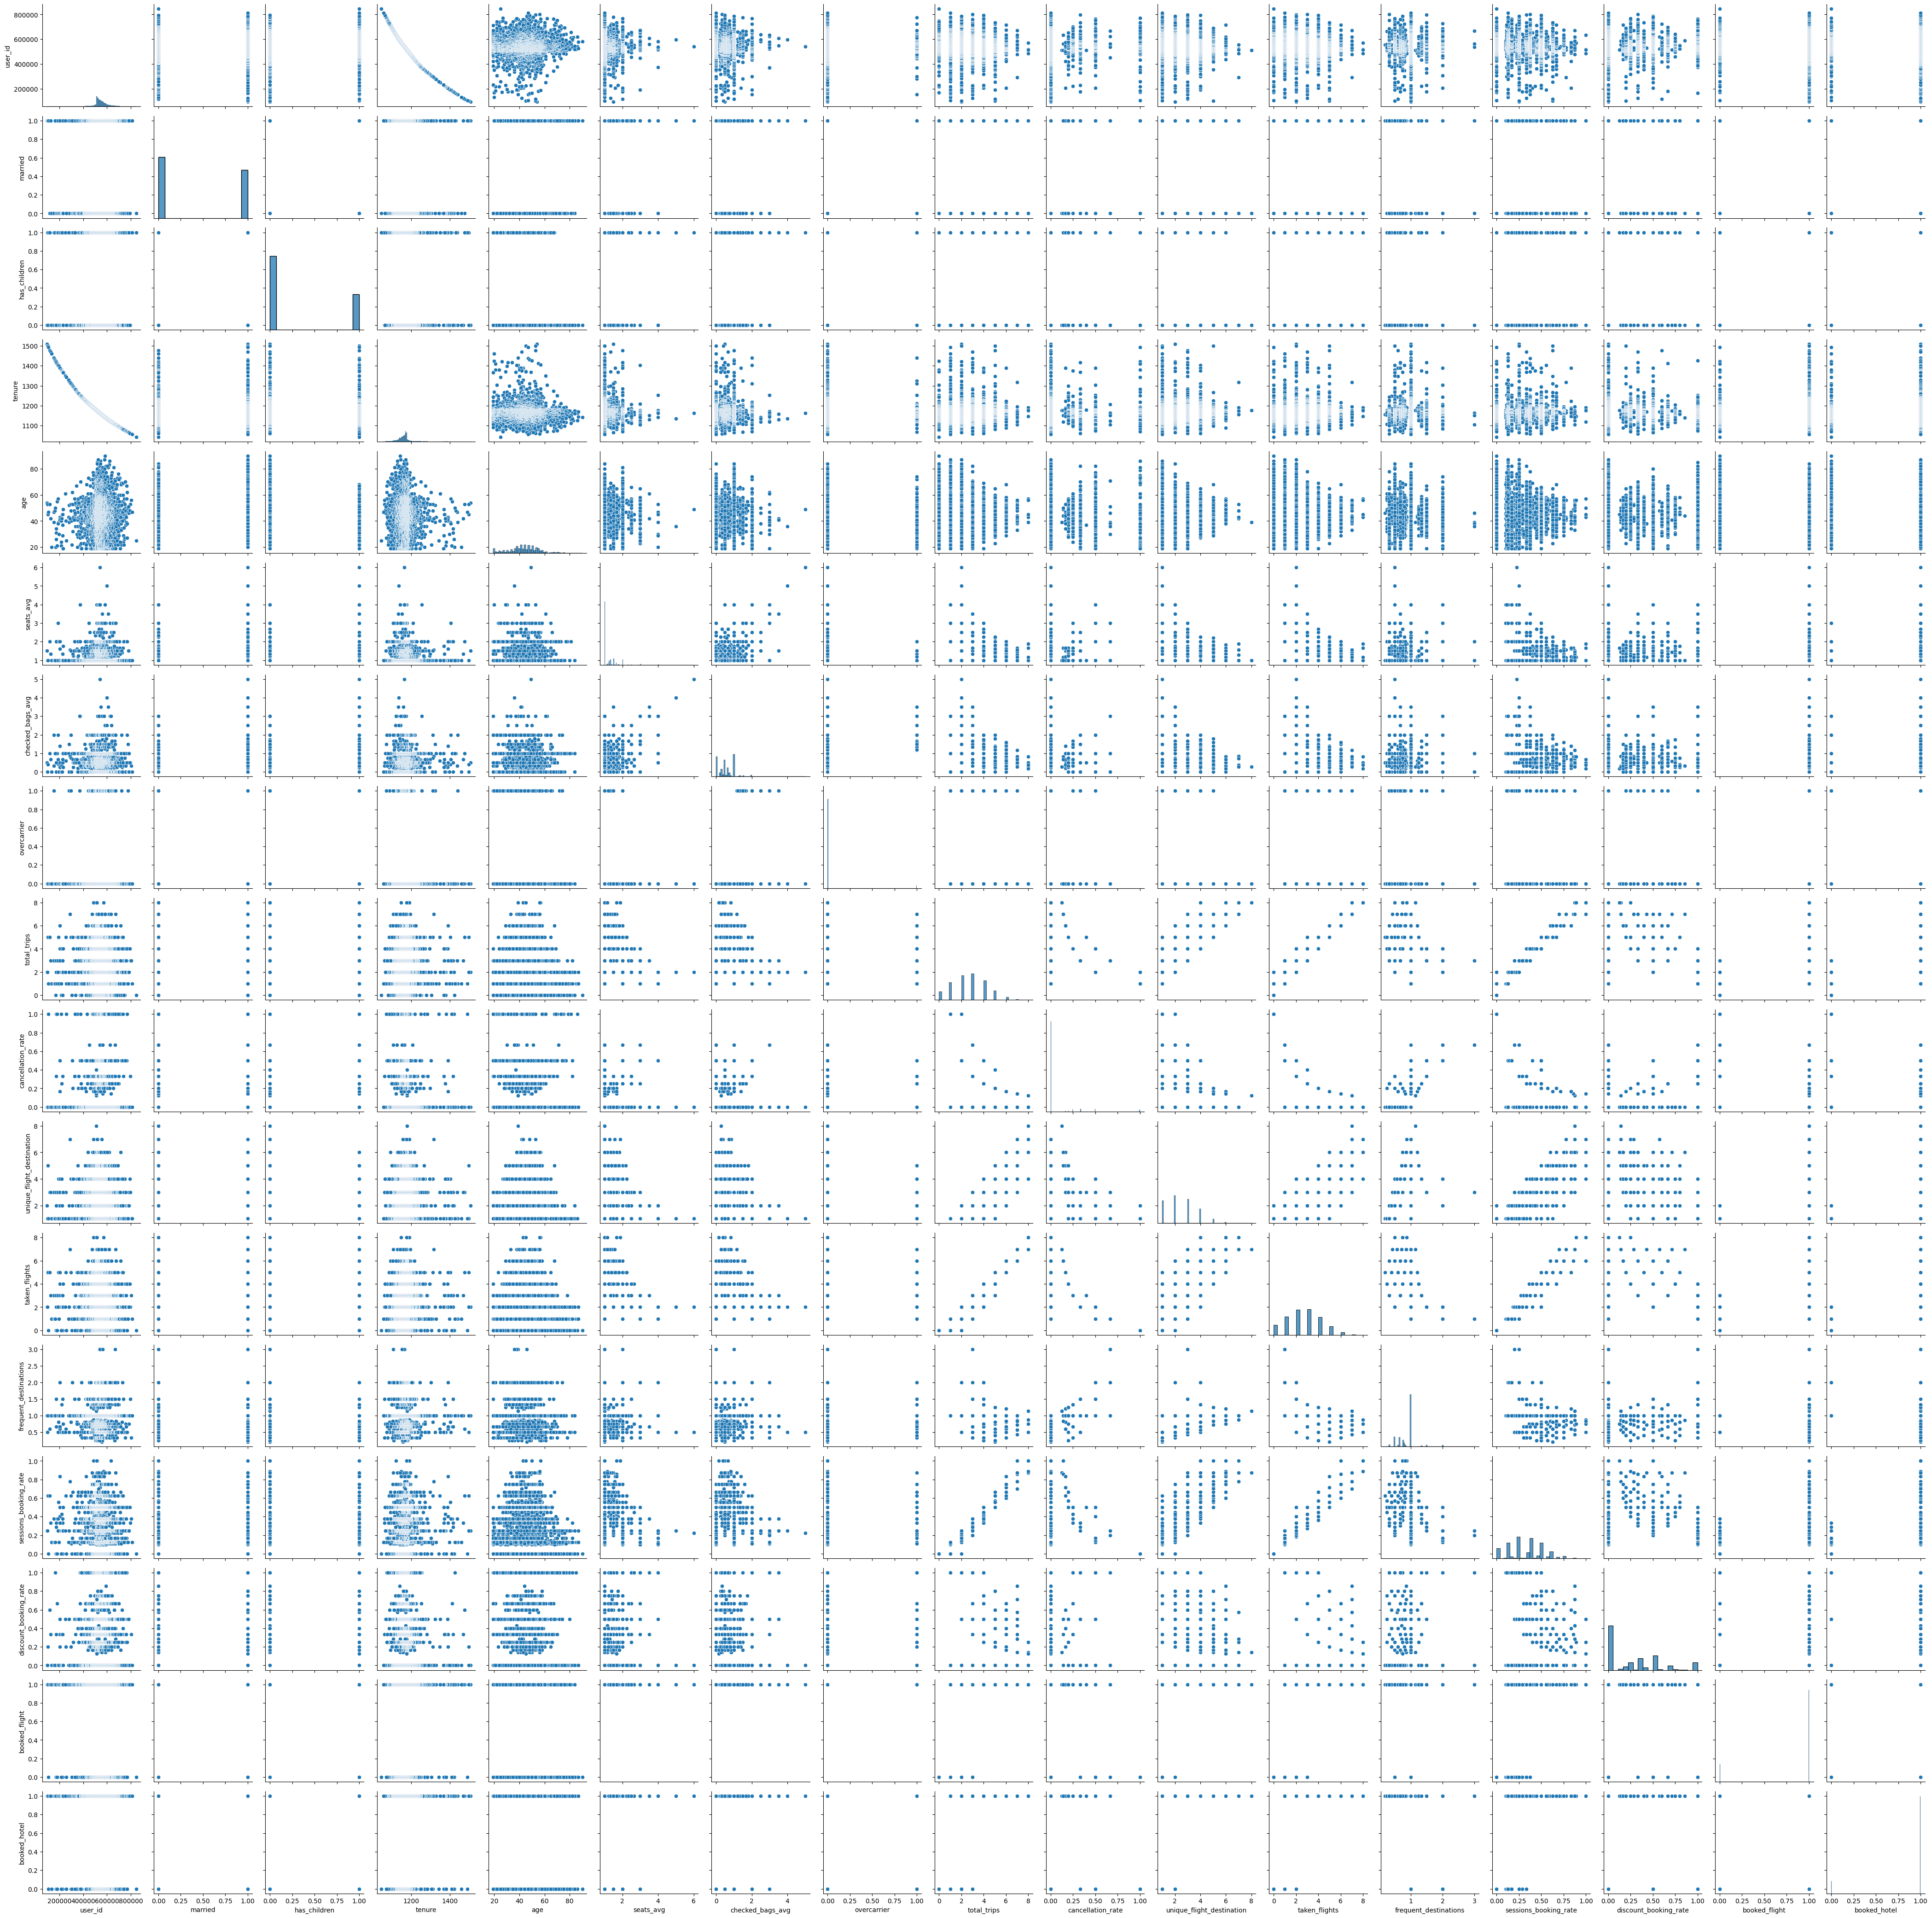

In [13]:
#sns.pairplot(user_features_all)

In [ ]:
#sns.pairplot(user_features_all)
#plt.savefig('pairplot_analysis.png')

In [14]:
user_features_all.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'tenure', 'age', 'seats_avg', 'checked_bags_avg', 'overcarrier',
       'total_trips', 'cancellation_rate', 'unique_flight_destination',
       'taken_flights', 'frequent_destinations', 'sessions_booking_rate',
       'discount_booking_rate', 'booked_flight', 'booked_hotel'],
      dtype='str')

In [ ]:
sns.pairplot(user_features_all[['age', 'tenure', 'seats_avg', 'checked_bags_avg', 'home_country']], corner=True, hue="home_country")

# Group Creation

## Senior and Young Group
We can clearly see that the customer can be divided in 3 different groups according to age.
young group <21, senior group >63.

In [15]:
senior_group = user_features_all[user_features_all['age'] >= 63].copy()  # group

In [16]:
young_group = user_features_all[user_features_all['age'] < 21].copy()  # group

Created Senior and Young group, we keep the rest for further analysis.

In [17]:
user_features = user_features_all[(user_features_all['age'] >= 21) & (user_features_all['age'] < 63)].copy()

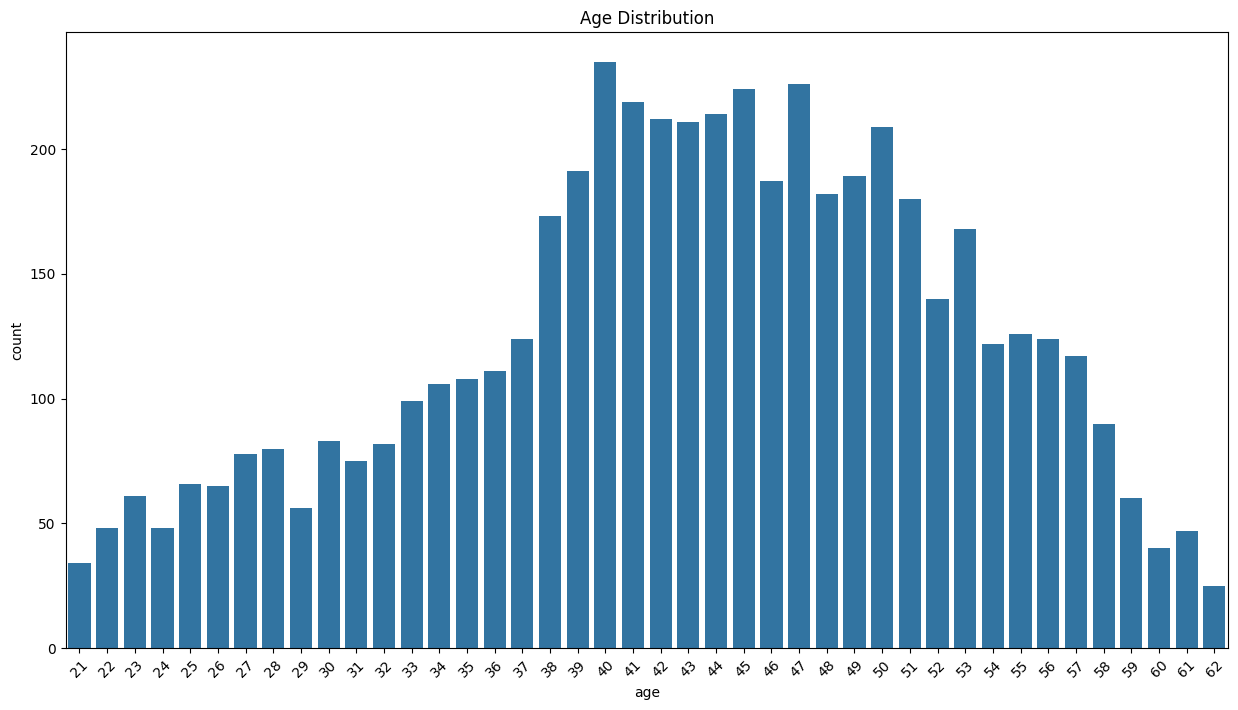

In [18]:
# Plot all countries with hue
plt.figure(figsize=(15, 8))
sns.countplot(data=user_features,
              x='age')
plt.title('Age Distribution')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

In [19]:
user_features_all

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,checked_bags_avg,overcarrier,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel
0,94883,F,True,False,usa,1509,54,1.5,0.5,False,2,0.0,2.0,2,1.0,0.250,0.0,True,True
1,101486,F,True,True,usa,1499,53,1.0,0.0,False,2,0.0,1.0,2,0.5,0.250,0.0,True,True
2,101961,F,True,False,usa,1499,45,1.0,0.4,False,5,0.0,5.0,5,1.0,0.625,0.2,True,True
3,106907,F,True,True,usa,1492,47,NaN,NaN,NaN,1,1.0,1.0,0,inf,0.000,NaN,False,False
4,118043,F,False,True,usa,1478,53,2.0,1.0,False,5,0.0,3.0,5,0.6,0.625,0.6,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,1067,51,1.5,0.0,False,2,0.0,2.0,2,1.0,0.250,0.5,True,True
5778,785186,F,True,True,usa,1065,46,1.0,0.0,False,2,0.0,2.0,2,1.0,0.250,0.0,True,True
5779,792549,F,False,False,usa,1062,48,1.0,0.5,False,4,0.0,4.0,4,1.0,0.500,0.0,True,True
5780,811077,F,True,True,usa,1056,47,1.0,0.0,False,1,0.0,1.0,1,1.0,0.125,0.0,True,True


## Family Travelers

In [20]:
family_traveler_group = user_features[(user_features['has_children'])&(user_features['married'])&(user_features["age"]<40)].copy()

In [21]:
user_features = user_features[~((user_features['has_children'])&(user_features['married'])&(user_features["age"]<40))].copy()

## Overcarriers

In [22]:
user_features['overcarrier'].value_counts(dropna=False)
# Carefull, only for example as there are only 7 customer

overcarrier
False    4406
NaN       542
True      126
Name: count, dtype: int64

In [23]:
overcarriers = user_features[user_features['overcarrier'] == True]
user_features = user_features[~(user_features['overcarrier'] == True)]

In [24]:
user_features.drop(columns=['overcarrier'], inplace=True)

## Booked trips

In [27]:
user_features[["booked_flight", "booked_hotel"]].value_counts(dropna=False)

booked_flight  booked_hotel
True           True            4325
False          False            326
               True             216
True           False             81
Name: count, dtype: int64

In [28]:
no_bookers_group = user_features[(user_features['booked_flight'] == False) & (user_features['booked_hotel'] == False)].copy()

user_features = user_features[~((user_features['booked_flight'] == False) & (user_features['booked_hotel'] == False))].copy()

## Save Rest for ML approach

In [29]:
user_features.shape

(4622, 18)

In [30]:
user_features.to_csv("data/users_no_group.csv", index=False)

In [31]:
overcarriers.to_csv("data/groups/overcarriers.csv", index=False)
senior_group.to_csv("data/groups/seniors.csv", index=False)
young_group.to_csv("data/groups/young.csv", index=False)
family_traveler_group.to_csv("data/groups/family_traveler.csv", index=False)
no_bookers_group.to_csv("data/groups/no_bookers_group.csv", index=False)
